In [9]:
import pandas as pd

df = pd.read_csv("logistics_data.csv")

# Basic info
df.info()

# Check missing values
df.isnull().sum()

# Delay distribution
df['Traffic_Status'].value_counts()

# Correlation
df.corr(numeric_only=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month_Name               1000 non-null   object 
 1   Month_Number             1000 non-null   int64  
 2   Hours                    1000 non-null   int64  
 3   Time                     1000 non-null   object 
 4   Date                     1000 non-null   object 
 5   Timestamp                1000 non-null   object 
 6   Asset_ID                 1000 non-null   object 
 7   Latitude                 1000 non-null   float64
 8   Longitude                1000 non-null   float64
 9   Inventory_Level          1000 non-null   int64  
 10  Shipment_Status          1000 non-null   object 
 11  Temperature              1000 non-null   float64
 12  Humidity                 1000 non-null   float64
 13  Traffic_Status           1000 non-null   object 
 14  Waiting_Time             

,Month_Number,Hours,Latitude,Longitude,Inventory_Level,Temperature,Humidity,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Asset_Utilization,Demand_Forecast,Logistics_Delay
Month_Number,1.000000,-0.026396,0.043631,-0.074965,0.013064,0.006429,-0.068977,0.032413,0.043965,0.008397,0.004379,-0.012880,-0.012343
Hours,-0.026396,1.000000,0.052049,0.013100,-0.018470,-0.014580,0.072521,0.025313,0.025531,0.030201,-0.008878,0.026006,0.020766
Latitude,0.043631,0.052049,1.000000,-0.000505,0.014805,-0.018830,-0.030202,-0.025667,-0.035171,0.003924,-0.023605,0.022110,0.039635
Longitude,-0.074965,0.013100,-0.000505,1.000000,-0.023186,0.007387,0.031622,0.031939,-0.019753,-0.036787,0.002916,0.098410,0.011797
Inventory_Level,0.013064,-0.018470,0.014805,-0.023186,1.000000,-0.021061,0.013395,-0.020337,-0.036785,-0.019701,0.017041,-0.016727,-0.003340
Temperature,0.006429,-0.014580,-0.018830,0.007387,-0.021061,1.000000,-0.022674,0.017392,-0.006377,-0.017139,0.046005,-0.010425,-0.038067
Humidity,-0.068977,0.072521,-0.030202,0.031622,0.013395,-0.022674,1.000000,0.029030,-0.034828,0.023341,-0.030637,-0.005887,-0.000504
Waiting_Time,0.032413,0.025313,-0.025667,0.031939,-0.020337,0.017392,0.029030,1.000000,-0.017796,0.023582,0.018008,-0.030042,-0.063036
User_Transaction_Amount,0.043965,0.025531,-0.035171,-0.019753,-0.036785,-0.006377,-0.034828,-0.017796,1.000000,0.038406,0.038607,0.004531,0.013605
User_Purchase_Frequency,0.008397,0.030201,0.003924,-0.036787,-0.019701,-0.017139,0.023341,0.023582,0.038406,1.000000,0.024445,-0.082900,-0.017439


In [18]:
df['Delay_Percentage'] = df['logistics_delay'] * 100

In [24]:
df = df.loc[:, ~df.columns.duplicated()]

In [25]:
for col in df.columns:
    print(col)

month_name
month_number
hours
time
date
timestamp
asset_id
latitude
longitude
inventory_level
shipment_status
temperature
humidity
traffic_status
waiting_time
user_transaction_amount
user_purchase_frequency
logistics_delay_reason
asset_utilization
demand_forecast
logistics_delay
delay_percentage


In [26]:
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

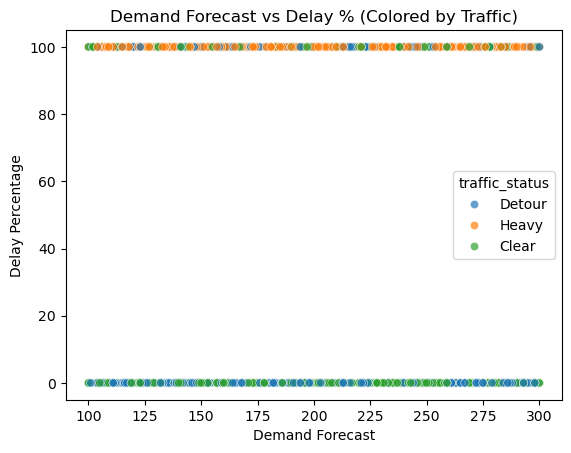

In [28]:
sns.scatterplot(
    data=df,
    x='demand_forecast',
    y='delay_percentage',
    hue='traffic_status',
    alpha=0.7
)

plt.title("Demand Forecast vs Delay % (Colored by Traffic)")
plt.xlabel("Demand Forecast")
plt.ylabel("Delay Percentage")
plt.show()